# 03 · Modelo Prophet
**Proyecto ML — Bizkaibus 2026**

Prophet (Meta) es especialmente adecuado para:
- Series con estacionalidad mensual marcada
- Datos con changepoints (COVID, subsidio)
- Predicción a futuro con incertidumbre

**Estrategia**: Un modelo por línea, con regresores externos (`flag_covid`, `flag_subsidio`).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# Carga de datos
train = pd.read_csv('../data/train.csv', parse_dates=['fecha'])
test  = pd.read_csv('../data/test.csv',  parse_dates=['fecha'])
df_all = pd.read_csv('../data/train_merged.csv', parse_dates=['fecha'])

lineas = sorted(df_all['linea'].unique())
print(f"Líneas a modelar: {len(lineas)}")
print(f"Train: {train['fecha'].min().date()} → {train['fecha'].max().date()} ({len(train):,} filas)")
print(f"Test:  {test['fecha'].min().date()} → {test['fecha'].max().date()} ({len(test):,} filas)")


c:\Users\rns_2\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Líneas a modelar: 104
Train: 2020-01-01 → 2024-12-01 (5,712 filas)
Test:  2025-01-01 → 2025-12-01 (1,140 filas)


## 1. Función auxiliar — entrenar y evaluar Prophet por línea

In [3]:
def entrenar_prophet(linea, train_df, test_df, regressors=True):
    """Entrena Prophet para una línea. Devuelve métricas y forecast."""
    
    # Preparar formato Prophet: ds, y
    tr = train_df[train_df['linea'] == linea].sort_values('fecha').copy()
    te = test_df[test_df['linea'] == linea].sort_values('fecha').copy()
    
    if len(tr) < 24:
        return None  # insuficientes datos
    
    tr_p = tr[['fecha','viajeros_total','flag_covid','flag_subsidio']].rename(
        columns={'fecha': 'ds', 'viajeros_total': 'y'})
    te_p = te[['fecha','viajeros_total','flag_covid','flag_subsidio']].rename(
        columns={'fecha': 'ds', 'viajeros_total': 'y'})
    
    # Configuración del modelo
    model = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.15,
        seasonality_prior_scale=10,
    )
    
    if regressors:
        model.add_regressor('flag_covid')
        model.add_regressor('flag_subsidio')
    
    model.fit(tr_p)
    
    # Predecir en test
    future = te_p[['ds','flag_covid','flag_subsidio']] if regressors else te_p[['ds']]
    forecast = model.predict(future)
    
    y_true = te_p['y'].values
    y_pred = forecast['yhat'].clip(lower=0).values
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    
    return {
        'linea': linea,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'model': model,
        'forecast_test': forecast,
        'y_true': y_true,
        'y_pred': y_pred,
        'tr_p': tr_p,
        'te_p': te_p,
    }

print("Función definida.")


Función definida.


## 2. Entrenamiento en todas las líneas

In [4]:
import time

resultados_prophet = {}
metricas_prophet = []
errores = []

start = time.time()
for i, linea in enumerate(lineas):
    try:
        res = entrenar_prophet(linea, train, test)
        if res:
            resultados_prophet[linea] = res
            metricas_prophet.append({
                'linea': linea,
                'mae': res['mae'],
                'rmse': res['rmse'],
                'mape': res['mape'],
            })
    except Exception as e:
        errores.append((linea, str(e)))
    
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(lineas)} líneas procesadas... ({time.time()-start:.0f}s)")

metricas_df = pd.DataFrame(metricas_prophet)
print(f"\n✓ Prophet entrenado para {len(metricas_df)} líneas en {time.time()-start:.0f}s")
if errores:
    print(f"  Errores en {len(errores)} líneas: {[e[0][:30] for e in errores[:3]]}")
print()
print("=== Métricas globales Prophet ===")
print(metricas_df[['mae','rmse','mape']].describe().round(2))


17:16:31 - cmdstanpy - INFO - Chain [1] start processing
17:16:34 - cmdstanpy - INFO - Chain [1] done processing
17:16:34 - cmdstanpy - INFO - Chain [1] start processing
17:16:35 - cmdstanpy - INFO - Chain [1] done processing
17:16:35 - cmdstanpy - INFO - Chain [1] start processing
17:16:35 - cmdstanpy - INFO - Chain [1] done processing
17:16:35 - cmdstanpy - INFO - Chain [1] start processing
17:16:35 - cmdstanpy - INFO - Chain [1] done processing
17:16:36 - cmdstanpy - INFO - Chain [1] start processing
17:16:36 - cmdstanpy - INFO - Chain [1] done processing
17:16:36 - cmdstanpy - INFO - Chain [1] start processing
17:16:36 - cmdstanpy - INFO - Chain [1] done processing
17:16:36 - cmdstanpy - INFO - Chain [1] start processing
17:16:37 - cmdstanpy - INFO - Chain [1] done processing
17:16:37 - cmdstanpy - INFO - Chain [1] start processing
17:16:37 - cmdstanpy - INFO - Chain [1] done processing
17:16:37 - cmdstanpy - INFO - Chain [1] start processing
17:16:38 - cmdstanpy - INFO - Chain [1]

  20/104 líneas procesadas... (11s)


17:16:42 - cmdstanpy - INFO - Chain [1] done processing
17:16:42 - cmdstanpy - INFO - Chain [1] start processing
17:16:42 - cmdstanpy - INFO - Chain [1] done processing
17:16:42 - cmdstanpy - INFO - Chain [1] start processing
17:16:43 - cmdstanpy - INFO - Chain [1] done processing
17:16:43 - cmdstanpy - INFO - Chain [1] start processing
17:16:43 - cmdstanpy - INFO - Chain [1] done processing
17:16:43 - cmdstanpy - INFO - Chain [1] start processing
17:16:44 - cmdstanpy - INFO - Chain [1] done processing
17:16:44 - cmdstanpy - INFO - Chain [1] start processing
17:16:44 - cmdstanpy - INFO - Chain [1] done processing
17:16:44 - cmdstanpy - INFO - Chain [1] start processing
17:16:44 - cmdstanpy - INFO - Chain [1] done processing
17:16:44 - cmdstanpy - INFO - Chain [1] start processing
17:16:45 - cmdstanpy - INFO - Chain [1] done processing
17:16:45 - cmdstanpy - INFO - Chain [1] start processing
17:16:45 - cmdstanpy - INFO - Chain [1] done processing
17:16:45 - cmdstanpy - INFO - Chain [1] 

  40/104 líneas procesadas... (36s)


17:17:08 - cmdstanpy - INFO - Chain [1] done processing
17:17:08 - cmdstanpy - INFO - Chain [1] start processing
17:17:08 - cmdstanpy - INFO - Chain [1] done processing
17:17:08 - cmdstanpy - INFO - Chain [1] start processing
17:17:09 - cmdstanpy - INFO - Chain [1] done processing
17:17:09 - cmdstanpy - INFO - Chain [1] start processing
17:17:09 - cmdstanpy - INFO - Chain [1] done processing
17:17:09 - cmdstanpy - INFO - Chain [1] start processing
17:17:09 - cmdstanpy - INFO - Chain [1] done processing
17:17:09 - cmdstanpy - INFO - Chain [1] start processing
17:17:10 - cmdstanpy - INFO - Chain [1] done processing
17:17:10 - cmdstanpy - INFO - Chain [1] start processing
17:17:10 - cmdstanpy - INFO - Chain [1] done processing
17:17:10 - cmdstanpy - INFO - Chain [1] start processing
17:17:10 - cmdstanpy - INFO - Chain [1] done processing
17:17:10 - cmdstanpy - INFO - Chain [1] start processing
17:17:11 - cmdstanpy - INFO - Chain [1] done processing
17:17:11 - cmdstanpy - INFO - Chain [1] 

...

  80/104 líneas procesadas... (50s)


17:17:21 - cmdstanpy - INFO - Chain [1] done processing
17:17:21 - cmdstanpy - INFO - Chain [1] start processing
17:17:22 - cmdstanpy - INFO - Chain [1] done processing
17:17:22 - cmdstanpy - INFO - Chain [1] start processing
17:17:22 - cmdstanpy - INFO - Chain [1] done processing
17:17:22 - cmdstanpy - INFO - Chain [1] start processing
17:17:23 - cmdstanpy - INFO - Chain [1] done processing
17:17:23 - cmdstanpy - INFO - Chain [1] start processing
17:17:23 - cmdstanpy - INFO - Chain [1] done processing
17:17:23 - cmdstanpy - INFO - Chain [1] start processing
17:17:24 - cmdstanpy - INFO - Chain [1] done processing
17:17:24 - cmdstanpy - INFO - Chain [1] start processing
17:17:24 - cmdstanpy - INFO - Chain [1] done processing
17:17:24 - cmdstanpy - INFO - Chain [1] start processing
17:17:24 - cmdstanpy - INFO - Chain [1] done processing
17:17:24 - cmdstanpy - INFO - Chain [1] start processing
17:17:25 - cmdstanpy - INFO - Chain [1] done processing
17:17:25 - cmdstanpy - INFO - Chain [1] 

  100/104 líneas procesadas... (57s)


17:17:28 - cmdstanpy - INFO - Chain [1] done processing
17:17:28 - cmdstanpy - INFO - Chain [1] start processing
17:17:29 - cmdstanpy - INFO - Chain [1] done processing
17:17:29 - cmdstanpy - INFO - Chain [1] start processing
17:17:29 - cmdstanpy - INFO - Chain [1] done processing
17:17:29 - cmdstanpy - INFO - Chain [1] start processing
17:17:29 - cmdstanpy - INFO - Chain [1] done processing



✓ Prophet entrenado para 91 líneas en 58s
  Errores en 4 líneas: ['BILBAO-LAUKIZ', 'BILBAO-LOIU-Lauroeta-DERIO', 'MUNGIA - DERIO - Cruces/Gurutz']

=== Métricas globales Prophet ===
            mae      rmse          mape
count     91.00     91.00  9.100000e+01
mean    2580.45   3360.90  6.618208e+11
std     2471.52   3140.78  2.880203e+12
min        0.00      0.00  3.530000e+00
25%      716.46    929.84  7.430000e+00
50%     1887.82   2466.49  9.970000e+00
75%     3651.37   4788.85  2.667000e+01
max    11328.54  13249.33  2.479961e+13


## 3. Visualización — mejores y peores líneas

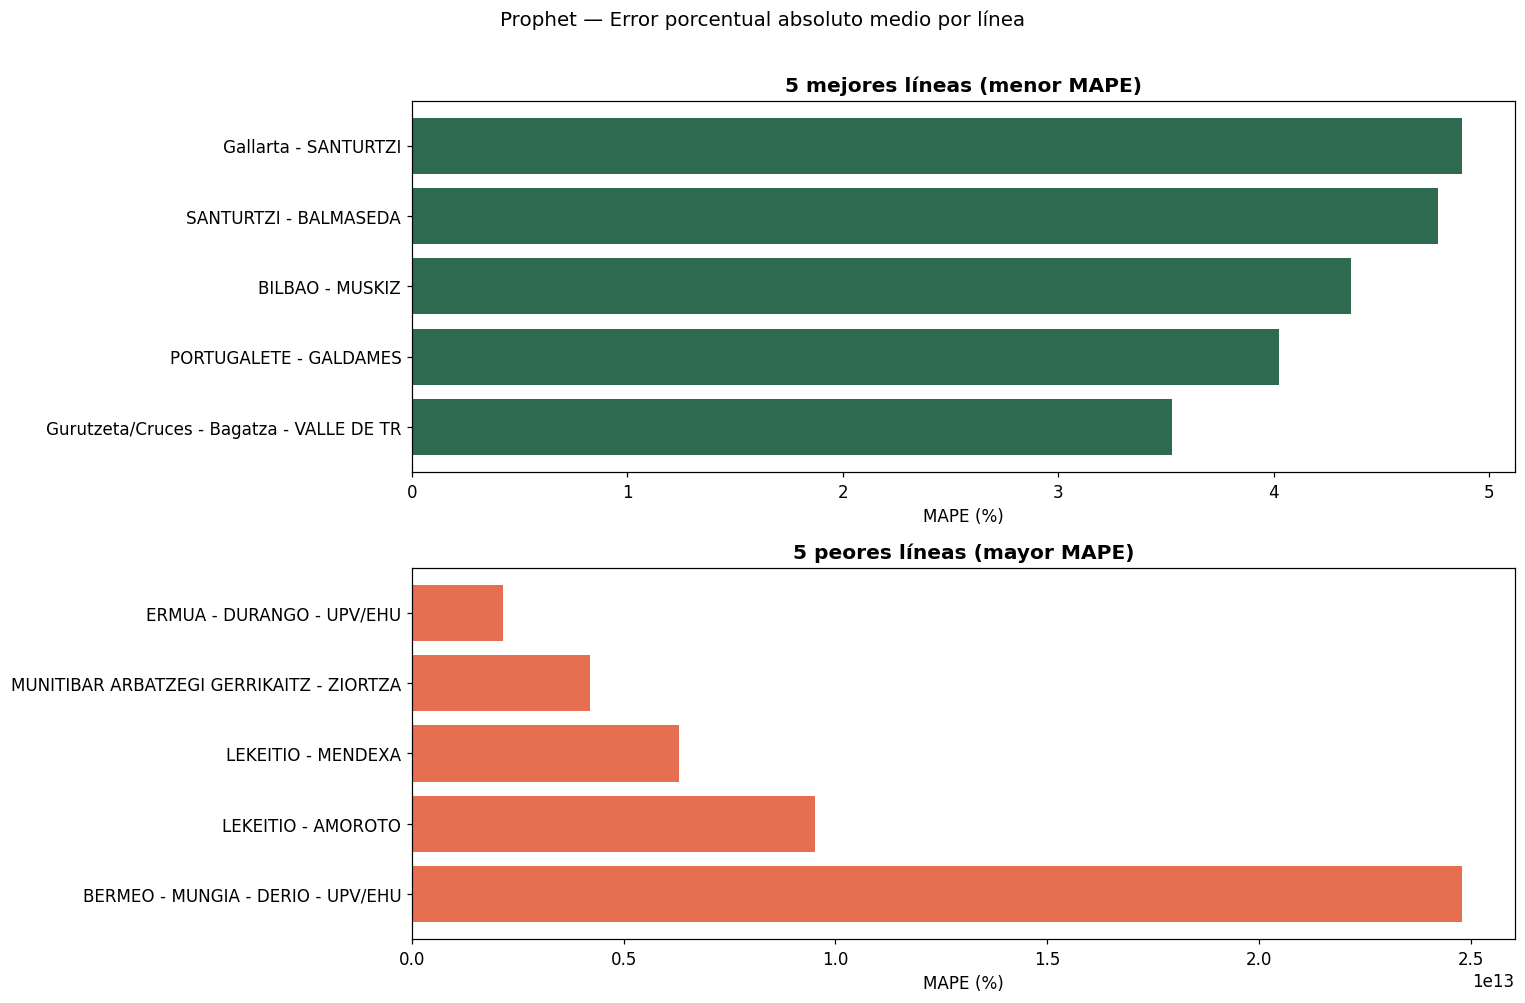

MAPE mediano: 9.97 %


In [6]:
# Top 5 y bottom 5 por MAPE
top5 = metricas_df.nsmallest(5, 'mape')
bot5 = metricas_df.nlargest(5, 'mape')

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, subset, titulo in zip(axes, [top5, bot5], 
                               ['5 mejores líneas (menor MAPE)', '5 peores líneas (mayor MAPE)']):
    ax.barh(subset['linea'].str[:40], subset['mape'], color='#2d6a4f' if 'mejor' in titulo else '#e76f51')
    ax.set_xlabel('MAPE (%)')
    ax.set_title(titulo, fontweight='bold')
plt.suptitle('Prophet — Error porcentual absoluto medio por línea', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("MAPE mediano:", metricas_df['mape'].median().round(2), "%")


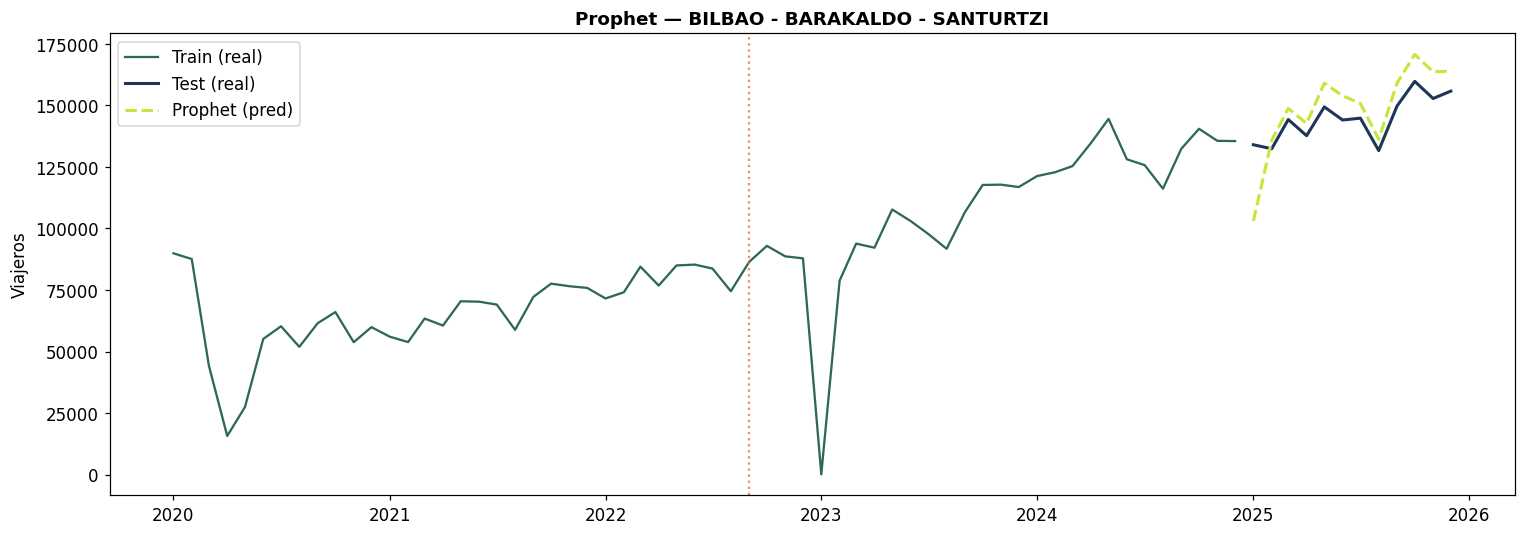

MAPE en esta línea: 6.6%


In [7]:
# Visualización detallada para la línea con más viajeros
linea_ref = train.groupby('linea')['viajeros_total'].sum().idxmax()
res = resultados_prophet[linea_ref]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(res['tr_p']['ds'], res['tr_p']['y'], color='#2d6a4f', label='Train (real)', linewidth=1.5)
ax.plot(res['te_p']['ds'], res['y_true'], color='#1d3557', label='Test (real)', linewidth=2)
ax.plot(res['te_p']['ds'], res['y_pred'], color='#c8e63a', label='Prophet (pred)', 
        linewidth=2, linestyle='--')
ax.axvline(pd.Timestamp('2022-09-01'), color='#e76f51', linewidth=1.5, linestyle=':', alpha=0.8)
ax.set_title(f'Prophet — {linea_ref[:50]}', fontsize=12, fontweight='bold')
ax.set_ylabel('Viajeros')
ax.legend()
plt.tight_layout()
plt.show()
print(f"MAPE en esta línea: {res['mape']:.1f}%")


## 4. Predicción 2026

In [8]:
# Predicción para 2026 con todos los modelos entrenados
predicciones_2026 = []

for linea, res in resultados_prophet.items():
    model = res['model']
    
    # Crear futuro: 12 meses de 2026
    future_2026 = pd.DataFrame({
        'ds': pd.date_range('2026-01-01', periods=12, freq='MS'),
        'flag_covid': 0,
        'flag_subsidio': 1,
    })
    
    forecast_2026 = model.predict(future_2026)
    
    for _, row in forecast_2026.iterrows():
        predicciones_2026.append({
            'linea': linea,
            'fecha': row['ds'],
            'año': 2026,
            'mes': row['ds'].month,
            'viajeros_pred_prophet': max(0, row['yhat']),
            'viajeros_pred_lower': max(0, row['yhat_lower']),
            'viajeros_pred_upper': max(0, row['yhat_upper']),
        })

pred_2026_df = pd.DataFrame(predicciones_2026)
pred_2026_df.to_csv('../data/predicciones_2026_prophet.csv', index=False)
print(f"✓ Predicciones 2026 guardadas: {pred_2026_df.shape}")
print()
# Total predicho para 2026
total_2026 = pred_2026_df.groupby('fecha')['viajeros_pred_prophet'].sum()
total_2025 = df_all[df_all['año']==2025].groupby('fecha')['viajeros_total'].sum()
crecimiento = (total_2026.sum() - total_2025.sum()) / total_2025.sum() * 100
print(f"Total viajeros 2025 (real):     {total_2025.sum()/1e6:.2f}M")
print(f"Total viajeros 2026 (pred):     {total_2026.sum()/1e6:.2f}M")
print(f"Crecimiento predicho:           {crecimiento:+.1f}%")


✓ Predicciones 2026 guardadas: (1092, 7)

Total viajeros 2025 (real):     34.09M
Total viajeros 2026 (pred):     36.73M
Crecimiento predicho:           +7.7%


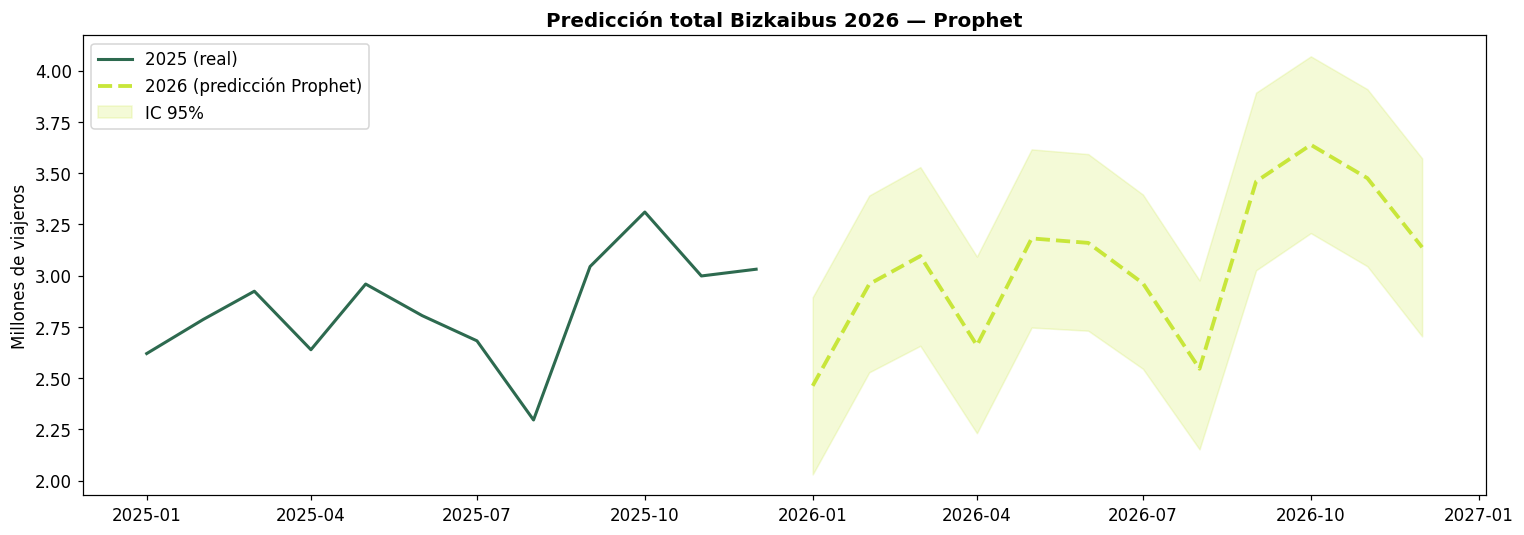

In [9]:
# Guardar métricas Prophet
metricas_df.to_csv('../data/metricas_prophet.csv', index=False)

# Gráfico: total mensual real vs predicho 2026
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(total_2025.index, total_2025.values / 1e6, color='#2d6a4f', 
        linewidth=2, label='2025 (real)')
ax.plot(total_2026.index, total_2026.values / 1e6, color='#c8e63a', 
        linewidth=2.5, linestyle='--', label='2026 (predicción Prophet)')
# Banda de confianza agregada
lower = pred_2026_df.groupby('fecha')['viajeros_pred_lower'].sum()
upper = pred_2026_df.groupby('fecha')['viajeros_pred_upper'].sum()
ax.fill_between(total_2026.index, lower/1e6, upper/1e6, alpha=0.2, color='#c8e63a', label='IC 95%')
ax.set_title('Predicción total Bizkaibus 2026 — Prophet', fontsize=13, fontweight='bold')
ax.set_ylabel('Millones de viajeros')
ax.legend()
plt.tight_layout()
plt.show()
